<a href="https://colab.research.google.com/github/niteshn20/Startup-Prediction-System/blob/main/ST_predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving startup_data.csv to startup_data.csv


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [ ]:
df = pd.read_csv("startup_data.csv")

df.replace(["-", "NA", "N/A", "", "null"], np.nan, inplace=True)


df['founded_at'] = pd.to_datetime(df['founded_at'], errors='coerce')
df['founded_year'] = df['founded_at'].dt.year
df['startup_age'] = 2024 - df['founded_year']


df = df[['funding_total_usd', 'funding_rounds', 'category_list',
         'country_code', 'startup_age', 'status']]

In [ ]:
numeric_cols = ['funding_total_usd','funding_rounds','startup_age']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')


df.fillna(df.mean(numeric_only=True), inplace=True)
df.fillna("Unknown", inplace=True)

In [ ]:
df['survival'] = df['status'].apply(lambda x: 1 if x in ['operating','ipo','acquired'] else 0)
df.drop('status', axis=1, inplace=True)


le_category = LabelEncoder()
le_country = LabelEncoder()
df['category_list'] = le_category.fit_transform(df['category_list'])
df['country_code'] = le_country.fit_transform(df['country_code'])

In [ ]:
X = df.drop('survival', axis=1)
y = df['survival']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Before SMOTE:\n", y_train.value_counts())
print("After SMOTE:\n", y_train_res.value_counts())

Before SMOTE:
 survival
1    48104
0     4990
Name: count, dtype: int64
After SMOTE:
 survival
1    48104
0    48104
Name: count, dtype: int64


In [ ]:
model = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

model.fit(X_train_res, y_train_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_proba = model.predict_proba(X_test)[:,1]
threshold = 0.3
y_pred = (y_pred_proba >= threshold).astype(int)

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[  154  1094]
 [  259 11767]]


In [ ]:
# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.37      0.12      0.19      1248
           1       0.91      0.98      0.95     12026

    accuracy                           0.90     13274
   macro avg       0.64      0.55      0.57     13274
weighted avg       0.86      0.90      0.87     13274



In [ ]:
# Accuracy & ROC-AUC
acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"Accuracy: {acc}")
print(f"ROC-AUC: {roc_auc:.3f}")

Accuracy: 0.8980714178092511
ROC-AUC: 0.713


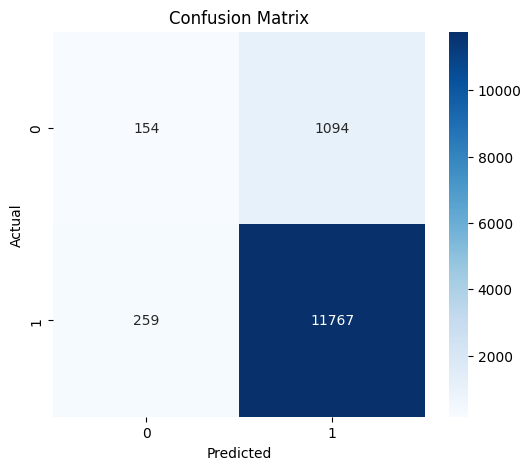

In [ ]:
#Plot Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

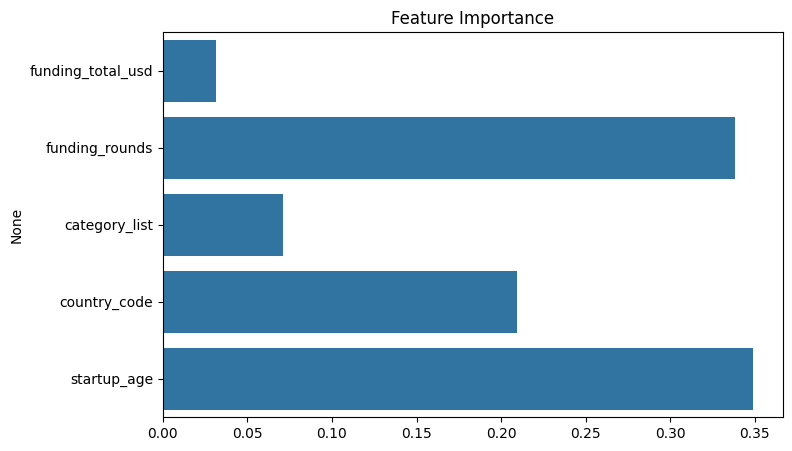

In [ ]:
# Feature Importance
plt.figure(figsize=(8,5))
sns.barplot(x=model.feature_importances_, y=X.columns)
plt.title("Feature Importance")
plt.show()

In [ ]:
# Save Model & Encoders
pickle.dump(model, open("startup_survival_model.pkl", "wb"))
pickle.dump(le_category, open("le_category.pkl", "wb"))
pickle.dump(le_country, open("le_country.pkl", "wb"))

print("Model and encoders saved successfully!")

✅ Model and encoders saved successfully!


In [ ]:
from google.colab import files

files.download("startup_survival_model.pkl")
files.download("le_category.pkl")
files.download("le_country.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df.head()

,funding_total_usd,funding_rounds,category_list,country_code,startup_age,survival
0,1.000000e+07,1,24912,55,16.371533,1
1,7.000000e+05,2,4651,130,10.000000,1
2,3.406878e+06,1,5312,132,16.371533,1
3,2.000000e+06,1,14525,23,17.000000,1
4,1.847860e+07,1,26968,130,14.000000,1
